In [3]:
text = "This movie was NOT good!"

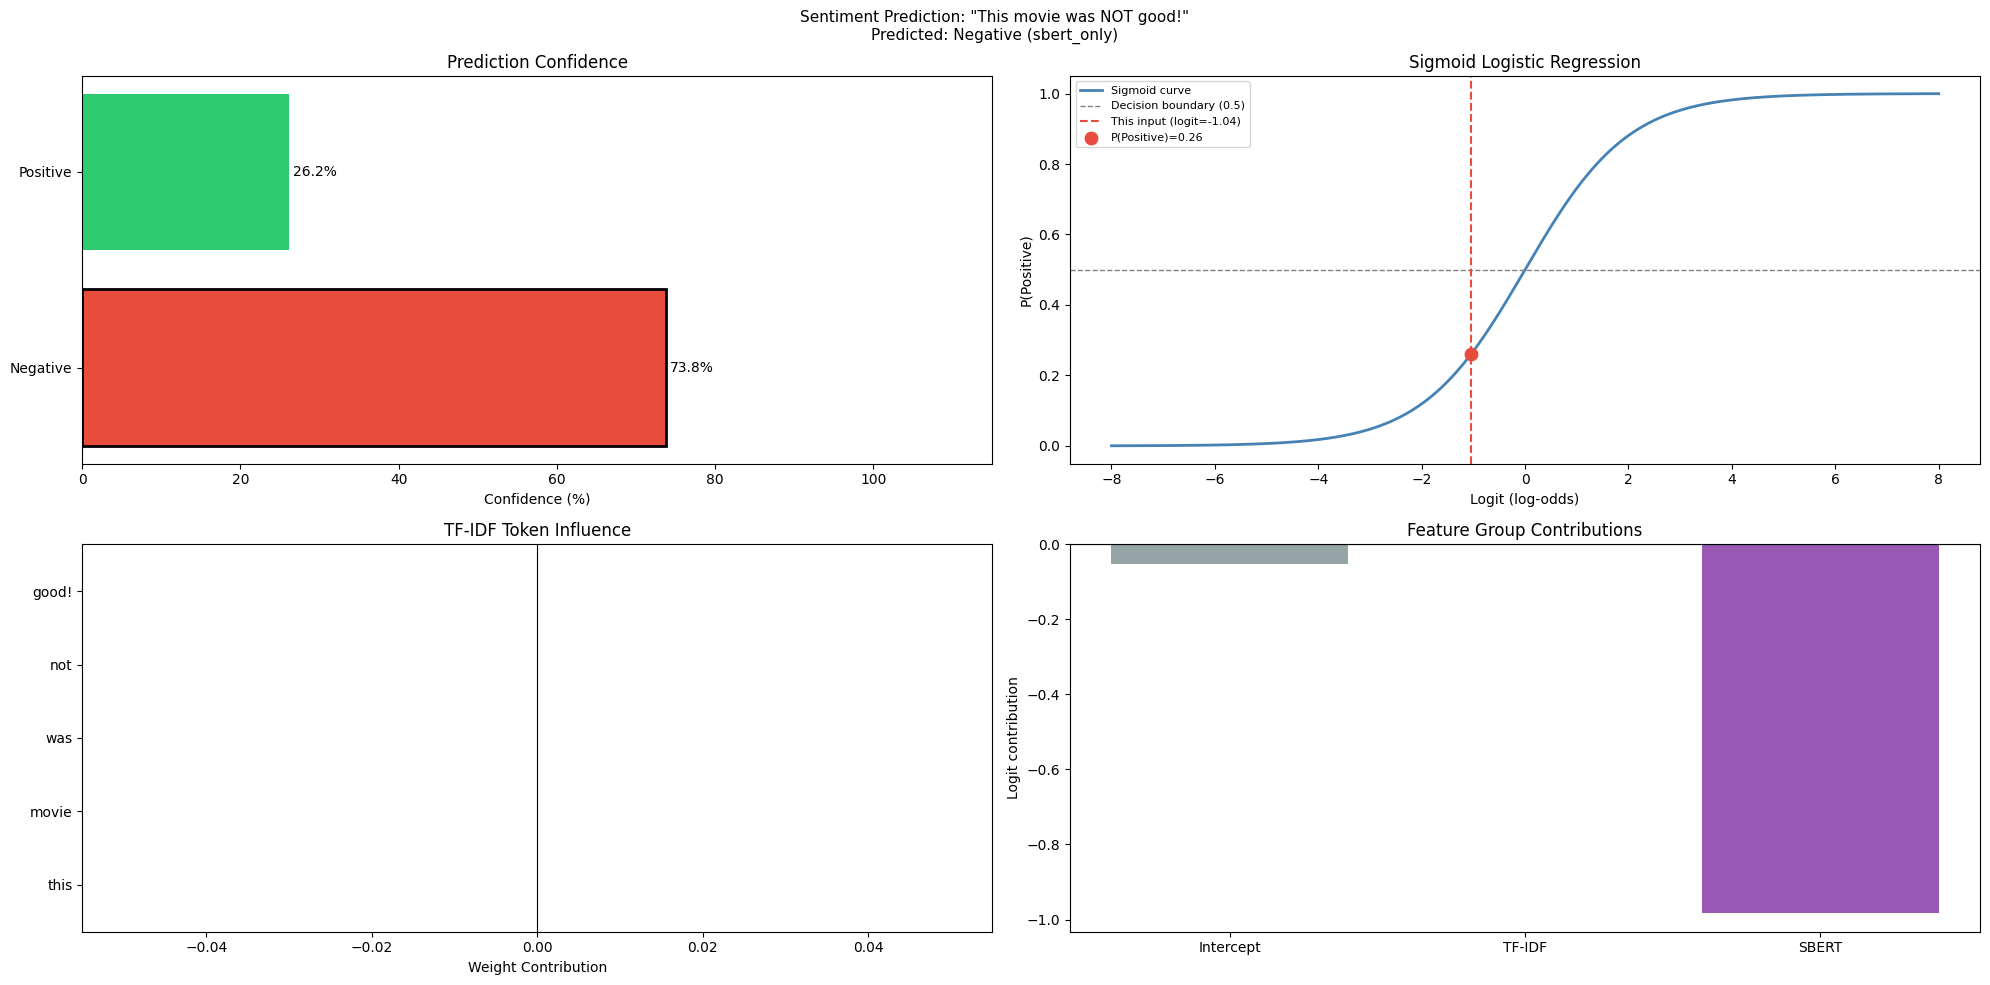

text: "This movie was NOT good!" | result: {'sentiment': 'Negative', 'confidence': np.float32(73.83), 'token_weights': [{'word': 'This', 'weight': 0.0}, {'word': 'movie', 'weight': 0.0}, {'word': 'was', 'weight': 0.0}, {'word': 'NOT', 'weight': 0.0}, {'word': 'good!', 'weight': 0.0}], 'sbert_summary': {'mode': 'sbert_only', 'embedding_norm_l2': 0.5932359099388123, 'tfidf_logit': 0.0, 'sbert_logit': -0.983371, 'intercept_logit': -0.053735, 'total_logit': -1.037106, 'prob_positive': 0.261709, 'top_sbert_dimensions': [{'dimension': 22, 'value': 0.08249791711568832, 'coef': 14.171040534973145, 'contribution': 1.1690813302993774}, {'dimension': 57, 'value': -0.06303976476192474, 'coef': -14.81671142578125, 'contribution': 0.9340419769287109}, {'dimension': 28, 'value': -0.14071573317050934, 'coef': 6.522881984710693, 'contribution': -0.9178721308708191}, {'dimension': 59, 'value': -0.07655616104602814, 'coef': -10.52324104309082, 'contribution': 0.805618941783905}, {'dimension': 14, 'value'

In [4]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from common import utils

for mode in ("hybrid", "tfidf_only", "sbert_only"):
    print(f"\n{'='*40}")
    print(f"  MODE: {mode.upper()}")
    print(f"{'='*40}")
    try:
        analyse = utils.SentimentAnalyser(
            args=["train-for-me=true"],
            mode=mode
        )
        result = analyse.predict(text, enable_plt=(mode == "hybrid"))
        print(f"text:   \"{text}\"")
        print(f"result: {result['label']}  ({result['positive_probability']*100:.1f}% positive)")
        print(f"logits → intercept: {result['intercept']:.4f} | "
              f"tfidf: {result['tfidf_logit']:.4f} | "
              f"sbert: {result['sbert_logit']:.4f} | "
              f"total: {result['total_logit']:.4f}")
    except Exception as e:
        print(f"[ERROR] {e}")
